In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import precision_score, recall_score, f1_score

In [2]:
# ========== CONFIG ==========
DATA_DIR = "/kaggle/input/mid-sd-food101-reddit-resizeonly-split/Mid_SD_Food101_Reddit_ResizeOnly_Split"
BATCH_SIZE = 32
NUM_WORKERS = 4
NUM_EPOCHS = 30
NUM_CLASSES = 2
IMAGE_SIZE = (224, 224)
IMG_HEIGHT, IMG_WIDTH = 224, 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_SAVE_PATH = "resnet18.pth"
METRICS_CSV_PATH = "training_metrics.csv"

print("Using device:", DEVICE)

Using device: cuda


In [3]:
# ===== ALBUMENTATIONS PIPELINES =====
train_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), sigma_limit=(0.1, 2.0), p=0.3),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    A.ImageCompression(quality_lower=75, quality_upper=90, p=0.4),  # JPEG compression
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_test_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# ===== CUSTOM DATASET WRAPPER =====
class AlbumentationsImageDataset(ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root)
        self.albumentations_transform = transform

    def __getitem__(self, index):
        path, label = self.samples[index]
        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.albumentations_transform:
            image = self.albumentations_transform(image=image)["image"]

        return image, label

# ===== LOAD DATASETS =====
image_datasets = {
    'train': AlbumentationsImageDataset(os.path.join(DATA_DIR, 'train'), transform=train_transform),
    'val': AlbumentationsImageDataset(os.path.join(DATA_DIR, 'val'), transform=val_test_transform),
    'test': AlbumentationsImageDataset(os.path.join(DATA_DIR, 'test'), transform=val_test_transform)
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE,
                  shuffle=True if x == 'train' else False,
                  num_workers=NUM_WORKERS)
    for x in ['train', 'val', 'test']
}

/tmp/ipykernel_19/2451684665.py:8: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
/tmp/ipykernel_19/2451684665.py:9: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, quality_upper=90, p=0.4),  # JPEG compression


In [4]:
# ========== MODEL ==========
#RESNET=========================================
# model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
# model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
# for param in model.parameters():
#    param.requires_grad = False
# model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
# model = model.to(DEVICE)

# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

#EfficientNet===================================
# model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
# in_features = model.classifier[1].in_features
# model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)
# model = model.to(DEVICE)

# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.classifier[1].parameters(), lr=1e-4)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

#ConvNeXtV2
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier[2].parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth
100%|██████████| 109M/109M [00:00<00:00, 187MB/s]


In [5]:
# Metrics history
history = {
    "epoch": [],
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "train_precision": [], "val_precision": [],
    "train_recall": [], "val_recall": [],
    "train_f1": [], "val_f1": []
}

def calculate_metrics(y_true, y_pred):
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return precision, recall, f1

def train_model(model, dataloaders, criterion, optimizer, num_epochs=NUM_EPOCHS):
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0
            all_labels = []
            all_preds = []

            for inputs, labels in tqdm(dataloaders[phase], desc=f"{phase} loop"):
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)
            precision, recall, f1 = calculate_metrics(all_labels, all_preds)

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc.item())
            history[f"{phase}_precision"].append(precision)
            history[f"{phase}_recall"].append(recall)
            history[f"{phase}_f1"].append(f1)

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} "
                  f"Prec: {precision:.4f} Recall: {recall:.4f} F1: {f1:.4f}")

        history["epoch"].append(epoch+1)

    torch.save(model.state_dict(), MODEL_SAVE_PATH)
    print(f"✅ Model saved to {MODEL_SAVE_PATH}")
    return model

def evaluate(model, dataloader):
    model.eval()
    all_labels, all_preds = [], []
    running_loss, running_corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Testing"):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    test_loss = running_loss / len(dataloader.dataset)
    test_acc = running_corrects.double() / len(dataloader.dataset)
    precision, recall, f1 = calculate_metrics(all_labels, all_preds)
    print(f"\nTest Loss: {test_loss:.4f} Acc: {test_acc:.4f} "
          f"Prec: {precision:.4f} Recall: {recall:.4f} F1: {f1:.4f}")

    # Append to CSV history
    history["epoch"].append("test")
    history["train_loss"].append(None)
    history["val_loss"].append(test_loss)
    history["train_acc"].append(None)
    history["val_acc"].append(test_acc.item())
    history["train_precision"].append(None)
    history["val_precision"].append(precision)
    history["train_recall"].append(None)
    history["val_recall"].append(recall)
    history["train_f1"].append(None)
    history["val_f1"].append(f1)

In [6]:
# ==== TRAIN ====
trained_model = train_model(model, dataloaders, criterion, optimizer)


Epoch 1/30


train loop: 100%|██████████| 719/719 [08:25<00:00,  1.42it/s]


Train Loss: 0.4800 Acc: 0.8109 Prec: 0.8111 Recall: 0.8110 F1: 0.8109


val loop: 100%|██████████| 154/154 [00:22<00:00,  6.79it/s]


Val Loss: 0.2853 Acc: 0.9163 Prec: 0.9211 Recall: 0.9167 F1: 0.9161

Epoch 2/30


...

Val Loss: 0.0894 Acc: 0.9669 Prec: 0.9678 Recall: 0.9671 F1: 0.9669

Epoch 30/30


train loop: 100%|██████████| 719/719 [08:26<00:00,  1.42it/s]


Train Loss: 0.1659 Acc: 0.9337 Prec: 0.9337 Recall: 0.9337 F1: 0.9337


val loop: 100%|██████████| 154/154 [00:18<00:00,  8.47it/s]


Val Loss: 0.0851 Acc: 0.9679 Prec: 0.9686 Recall: 0.9681 F1: 0.9679
✅ Model saved to resnet18.pth


In [7]:
# ==== TEST ====
evaluate(trained_model, dataloaders['test'])

Testing: 100%|██████████| 154/154 [00:20<00:00,  7.43it/s]


Test Loss: 0.0881 Acc: 0.9708 Prec: 0.9715 Recall: 0.9709 F1: 0.9708


📄 Metrics saved to training_metrics.csv


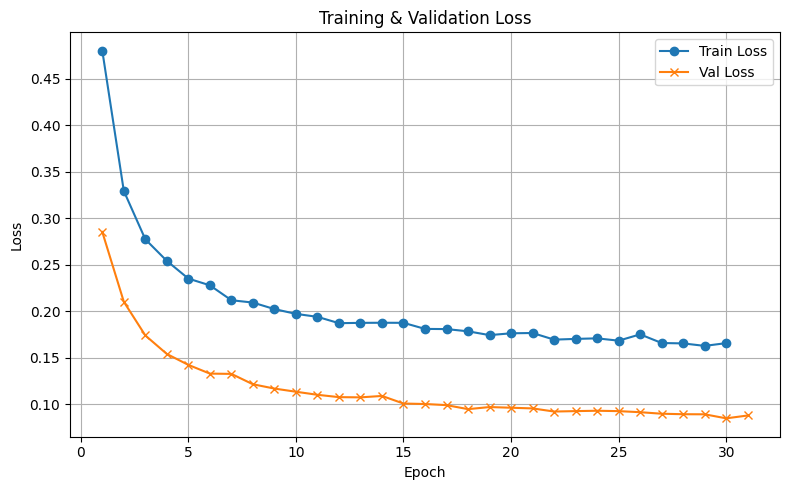

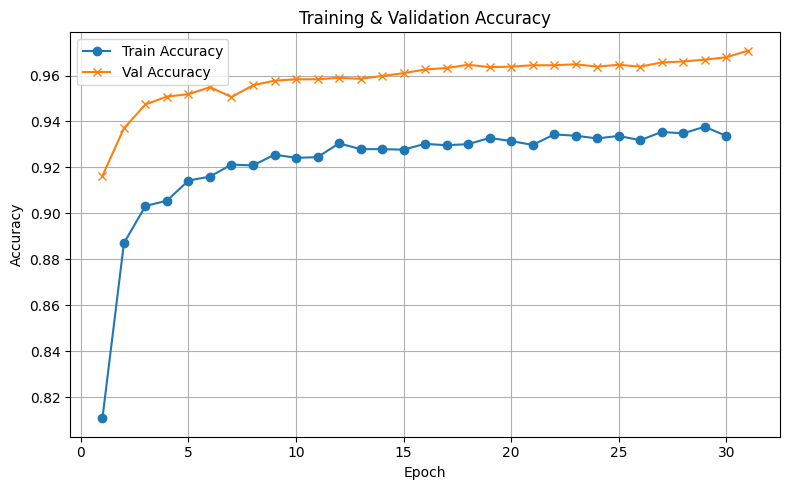

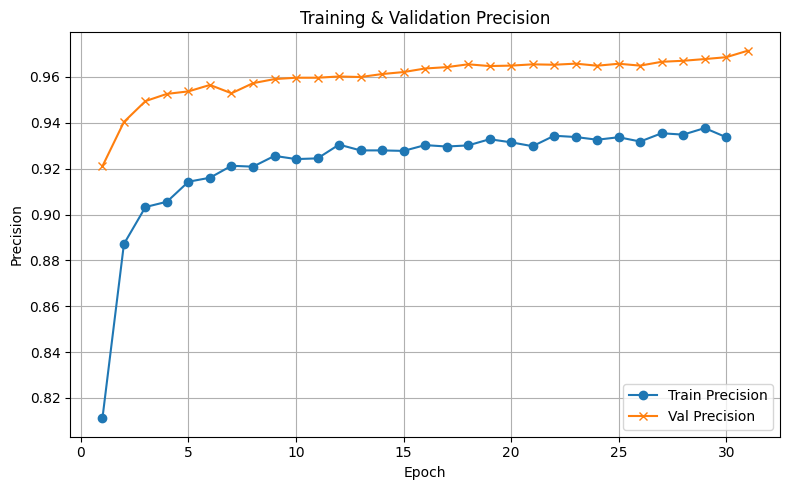

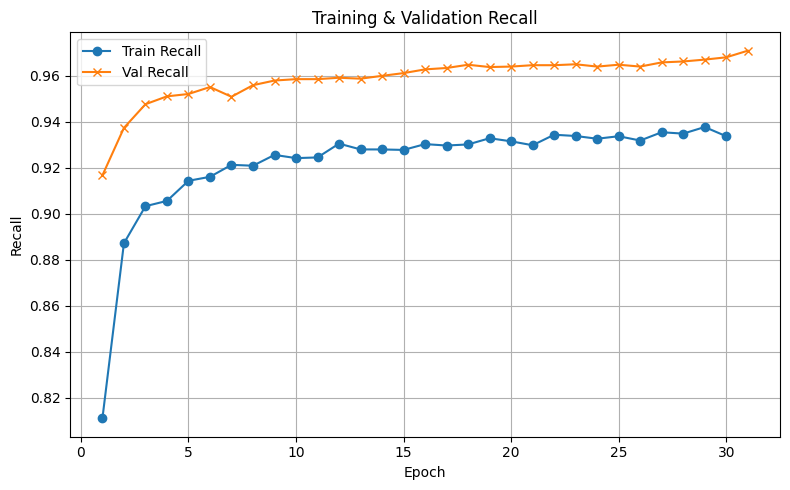

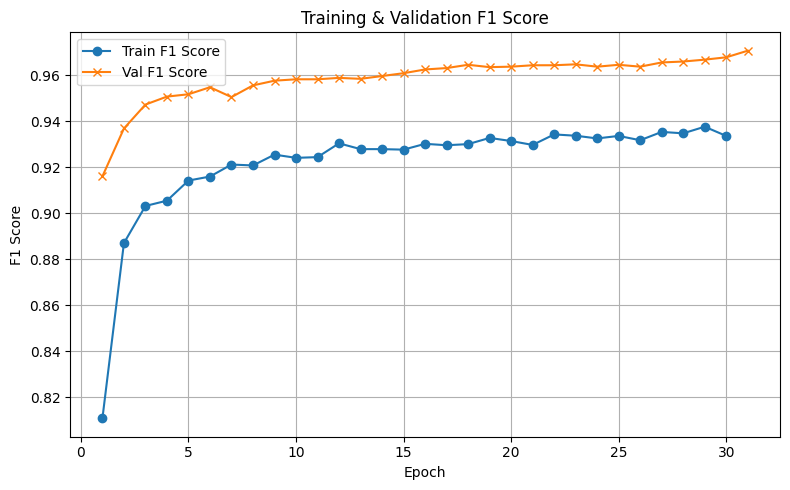

In [8]:
# ==== SAVE CSV ====
df = pd.DataFrame(history)
df.to_csv(METRICS_CSV_PATH, index=False)
print(f"📄 Metrics saved to {METRICS_CSV_PATH}")

# Plotting helper
def plot_metric(train, val, ylabel, title, filename):
    epochs = range(1, len(train)+1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train, label=f'Train {ylabel}', marker='o')
    plt.plot(epochs, val, label=f'Val {ylabel}', marker='x')
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

# Save plots
plot_metric(history['train_loss'], history['val_loss'], "Loss", "Training & Validation Loss", "loss_curve.png")
plot_metric(history['train_acc'], history['val_acc'], "Accuracy", "Training & Validation Accuracy", "accuracy_curve.png")
plot_metric(history['train_precision'], history['val_precision'], "Precision", "Training & Validation Precision", "precision_curve.png")
plot_metric(history['train_recall'], history['val_recall'], "Recall", "Training & Validation Recall", "recall_curve.png")
plot_metric(history['train_f1'], history['val_f1'], "F1 Score", "Training & Validation F1 Score", "f1_curve.png")